In [1]:
# Step 1 — Libraries
import pandas as pd
import sqlite3
import warnings
warnings.filterwarnings('ignore')



df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/data_cleaning.ipynb'
)

print(f"✅ Data loaded: {df.shape}")

# Step 3 — SQLite database banao (RAM mein)
conn = sqlite3.connect(':memory:')  # In-memory database
# ':memory:' matlab koi file nahi — RAM mein temporary database

# Step 4 — DataFrame ko SQL table mein daalo
df.to_sql('amazon_sales', conn,
          if_exists='replace',   # Table already hai toh replace karo
          index=False)            # DataFrame index column mat banana

print("✅ SQL table created: amazon_sales")
print(f"   Rows in table: {pd.read_sql('SELECT COUNT(*) as cnt FROM amazon_sales', conn).iloc[0,0]:,}")

✅ Data loaded: (128975, 28)
✅ SQL table created: amazon_sales
   Rows in table: 128,975


In [28]:
# Yeh function banao — baar baar use hoga
def run_query(sql, title=""):
    """SQL query chalao aur result print karo"""
    result = pd.read_sql(sql, conn)
    if title:
        print(f"\n{'='*50}")
        print(f"  {title}")
        print(f"{'='*50}")
    print(result.to_string(index=False))
    print(f"\n[{len(result)} rows returned]")
    return result

# Test karo
run_query("SELECT COUNT(*) as total_rows FROM amazon_sales",
          "Connection Test")


  Connection Test
 total_rows
     128975

[1 rows returned]


,total_rows
0,128975


In [5]:
sql_query = """
SELECT
    COUNT(DISTINCT "Order ID") AS total_orders,
    ROUND(SUM("Amount"), 2) AS total_revenue,
    ROUND(AVG("Amount"), 2) AS avg_order_value,
    SUM("Qty") AS total_units
FROM amazon_sales
WHERE "Amount" > 0;
"""

run_query(sql_query, "Query 1: Basic KPIs")


  Query 1: Basic KPIs
 total_orders  total_revenue  avg_order_value  total_units
       110687     78592678.3           661.35       114139

[1 rows returned]


,total_orders,total_revenue,avg_order_value,total_units
0,110687,78592678.3,661.35,114139


In [6]:
sql_query="""

-- Query 2: Category Performance
SELECT
    "Category",
    COUNT(DISTINCT "Order ID")   AS orders,
    ROUND(SUM("Amount"), 2)      AS revenue,
    ROUND(AVG("Amount"), 2)      AS avg_order_value,
    SUM("Qty")                   AS units_sold
FROM amazon_sales
WHERE "Amount" > 0
GROUP BY "Category"
ORDER BY revenue DESC;
"""
run_query(sql_query, "Query 2: Category Performance")


  Query 2: Category Performance
     Category  orders     revenue  avg_order_value  units_sold
          Set   43725 39204124.03           851.73       44212
        Kurta   42730 21299546.70           464.46       44112
Western Dress   13985 11216072.69           774.97       13708
          Top    9538  5347792.30           535.26        9725
 Ethnic Dress    1052   791217.66           745.73        1021
       Blouse     831   458408.18           533.65         822
       Bottom     380   150667.98           369.28         385
        Saree     134   123933.76           804.76         151
      Dupatta       2      915.00           305.00           3

[9 rows returned]


,Category,orders,revenue,avg_order_value,units_sold
0,Set,43725,39204124.03,851.73,44212
1,Kurta,42730,21299546.70,464.46,44112
2,Western Dress,13985,11216072.69,774.97,13708
3,Top,9538,5347792.30,535.26,9725
4,Ethnic Dress,1052,791217.66,745.73,1021
5,Blouse,831,458408.18,533.65,822
6,Bottom,380,150667.98,369.28,385
7,Saree,134,123933.76,804.76,151
8,Dupatta,2,915.00,305.00,3


In [7]:
sql_query="""-- Query 3: Monthly Revenue
SELECT
    strftime('%Y-%m', "Date")    AS year_month,
    strftime('%m', "Date")       AS month_num,
    COUNT(DISTINCT "Order ID")   AS orders,
    ROUND(SUM("Amount"), 2)      AS revenue
FROM amazon_sales
WHERE "Amount" > 0
GROUP BY strftime('%Y-%m', "Date")
ORDER BY year_month;
"""
run_query(sql_query, "Query 3: Monthly Revenue")


  Query 3: Monthly Revenue
year_month month_num  orders     revenue
   2022-01        01    4074  2880866.33
   2022-02        02    4299  2982101.41
   2022-03        03    4438  3042310.01
   2022-04        04   30062 20500095.00
   2022-05        05   24299 17821991.32
   2022-06        06   20988 15262409.88
   2022-07        07    3848  2787150.37
   2022-08        08    4044  2886262.76
   2022-09        09    3885  2742205.46
   2022-10        10    3649  2597647.85
   2022-11        11    3554  2553751.13
   2022-12        12    3547  2535886.78

[12 rows returned]


,year_month,month_num,orders,revenue
0,2022-01,01,4074,2880866.33
1,2022-02,02,4299,2982101.41
2,2022-03,03,4438,3042310.01
3,2022-04,04,30062,20500095.00
4,2022-05,05,24299,17821991.32
5,2022-06,06,20988,15262409.88
6,2022-07,07,3848,2787150.37
7,2022-08,08,4044,2886262.76
8,2022-09,09,3885,2742205.46
9,2022-10,10,3649,2597647.85


In [8]:
sql_query="""
-- Query 4: State-wise Performance
SELECT
    "ship-state"                 AS state,
    COUNT(DISTINCT "Order ID")   AS orders,
    ROUND(SUM("Amount"), 2)      AS revenue,
    ROUND(AVG("Amount"), 2)      AS avg_order_value
FROM amazon_sales
WHERE "Amount" > 0
  AND "ship-state" != 'Unknown'
GROUP BY "ship-state"
ORDER BY revenue DESC
LIMIT 10;
"""
run_query(sql_query, "Query 4: State-wise Performance")


  Query 4: State-wise Performance
         state  orders     revenue  avg_order_value
   Maharashtra   19237 13335534.14           646.13
     Karnataka   14964 10481114.37           652.46
     Telangana    9594  6916615.65           660.49
 Uttar Pradesh    9155  6816642.08           702.17
    Tamil Nadu    9718  6515650.11           612.83
         Delhi    5987  4346412.46           679.66
        Kerala    5628  3830227.58           630.80
   West Bengal    5148  3507880.44           645.19
Andhra Pradesh    4579  3219831.72           644.87
       Haryana    3833  2882092.99           705.36

[10 rows returned]


,state,orders,revenue,avg_order_value
0,Maharashtra,19237,13335534.14,646.13
1,Karnataka,14964,10481114.37,652.46
2,Telangana,9594,6916615.65,660.49
3,Uttar Pradesh,9155,6816642.08,702.17
4,Tamil Nadu,9718,6515650.11,612.83
5,Delhi,5987,4346412.46,679.66
6,Kerala,5628,3830227.58,630.80
7,West Bengal,5148,3507880.44,645.19
8,Andhra Pradesh,4579,3219831.72,644.87
9,Haryana,3833,2882092.99,705.36


In [9]:
sql_query="""
-- Query 5: Cancellation by Category
SELECT
    "Category",
    COUNT(*)                          AS total_orders,
    SUM(CASE WHEN "Status" = 'Cancelled'
             THEN 1 ELSE 0 END)       AS cancelled,
    ROUND(
      SUM(CASE WHEN "Status" = 'Cancelled'
               THEN 1 ELSE 0 END) * 100.0
      / COUNT(*), 2)                  AS cancel_rate_pct
FROM amazon_sales
GROUP BY "Category"
ORDER BY cancel_rate_pct DESC;
"""
run_query(sql_query, "Query 5: Cancellation by Category")


  Query 5: Cancellation by Category
     Category  total_orders  cancelled  cancel_rate_pct
          Set         50284       7337            14.59
        Kurta         49877       7255            14.55
Western Dress         15500       2122            13.69
       Bottom           440         60            13.64
        Saree           164         21            12.80
       Blouse           926        116            12.53
 Ethnic Dress          1159        145            12.51
          Top         10622       1276            12.01
      Dupatta             3          0             0.00

[9 rows returned]


,Category,total_orders,cancelled,cancel_rate_pct
0,Set,50284,7337,14.59
1,Kurta,49877,7255,14.55
2,Western Dress,15500,2122,13.69
3,Bottom,440,60,13.64
4,Saree,164,21,12.80
5,Blouse,926,116,12.53
6,Ethnic Dress,1159,145,12.51
7,Top,10622,1276,12.01
8,Dupatta,3,0,0.00


In [10]:
sql_query="""
-- Query 6: Top SKUs
SELECT
    "SKU",
    "Category",
    COUNT(DISTINCT "Order ID")    AS orders,
    SUM("Qty")                    AS units_sold,
    ROUND(SUM("Amount"), 2)       AS revenue,
    ROUND(AVG("Amount"), 2)       AS avg_price
FROM amazon_sales
WHERE "Amount" > 0
GROUP BY "SKU", "Category"
ORDER BY revenue DESC
LIMIT 10;
"""
run_query(sql_query, "Query 6: Top SKUs")


  Query 6: Top SKUs
            SKU      Category  orders  units_sold   revenue  avg_price
    J0230-SKD-M           Set     456         453 527699.20    1154.70
   JNE3797-KR-L Western Dress     707         646 524581.77     741.98
    J0230-SKD-S           Set     422         415 479937.14    1137.29
   JNE3797-KR-M Western Dress     607         547 454290.16     748.42
   JNE3797-KR-S Western Dress     545         495 407302.57     747.34
  JNE3797-KR-XL Western Dress     441         410 332155.24     753.19
    J0230-SKD-L           Set     262         258 305616.95    1166.48
  JNE3797-KR-XS Western Dress     404         383 303616.70     751.53
SET268-KR-NP-XL           Set     367         366 284058.96     774.00
JNE3797-KR-XXXL Western Dress     371         350 276375.80     744.95

[10 rows returned]


,SKU,Category,orders,units_sold,revenue,avg_price
0,J0230-SKD-M,Set,456,453,527699.20,1154.70
1,JNE3797-KR-L,Western Dress,707,646,524581.77,741.98
2,J0230-SKD-S,Set,422,415,479937.14,1137.29
3,JNE3797-KR-M,Western Dress,607,547,454290.16,748.42
4,JNE3797-KR-S,Western Dress,545,495,407302.57,747.34
5,JNE3797-KR-XL,Western Dress,441,410,332155.24,753.19
6,J0230-SKD-L,Set,262,258,305616.95,1166.48
7,JNE3797-KR-XS,Western Dress,404,383,303616.70,751.53
8,SET268-KR-NP-XL,Set,367,366,284058.96,774.00
9,JNE3797-KR-XXXL,Western Dress,371,350,276375.80,744.95


In [11]:
sql_query="""
-- Query 7: Fulfillment Performance Matrix
SELECT
    "Fulfilment",
    "Status",
    COUNT(DISTINCT "Order ID")   AS orders,
    ROUND(SUM("Amount"), 2)      AS revenue,
    ROUND(AVG("Amount"), 2)      AS avg_value
FROM amazon_sales
GROUP BY "Fulfilment", "Status"
ORDER BY "Fulfilment", orders DESC;
"""
run_query(sql_query, "Query 7: Fulfillment Performance Matrix")


  Query 7: Fulfillment Performance Matrix
Fulfilment                        Status  orders    revenue  avg_value
    Amazon                       Shipped   72826 50324255.0     646.81
    Amazon                     Cancelled   10803  3729112.0     325.09
    Amazon                       Pending     365   268784.0     647.67
    Amazon                      Shipping       8        0.0       0.00
  Merchant  Shipped - Delivered To Buyer   26566 18650815.0     648.30
  Merchant                     Cancelled    6382  3190172.3     464.97
  Merchant  Shipped - Returned To Seller    1851  1269644.0     650.10
  Merchant           Shipped - Picked Up     918   661252.0     679.60
  Merchant Pending - Waiting For Pick Up     262   192138.0     683.77
  Merchant                       Pending     219   161487.0     664.56
  Merchant Shipped - Returning To Seller     130   107620.0     742.21
  Merchant    Shipped - Out For Delivery      32    26971.0     770.60
  Merchant   Shipped - Rejected By

,Fulfilment,Status,orders,revenue,avg_value
0,Amazon,Shipped,72826,50324255.0,646.81
1,Amazon,Cancelled,10803,3729112.0,325.09
2,Amazon,Pending,365,268784.0,647.67
3,Amazon,Shipping,8,0.0,0.00
4,Merchant,Shipped - Delivered To Buyer,26566,18650815.0,648.30
5,Merchant,Cancelled,6382,3190172.3,464.97
6,Merchant,Shipped - Returned To Seller,1851,1269644.0,650.10
7,Merchant,Shipped - Picked Up,918,661252.0,679.60
8,Merchant,Pending - Waiting For Pick Up,262,192138.0,683.77
9,Merchant,Pending,219,161487.0,664.56


In [12]:
sql_query="""
-- Query 8: B2B vs B2C Comparison
SELECT
    CASE WHEN "B2B" = 'True' THEN 'B2B'
         ELSE 'B2C' END              AS customer_type,
    COUNT(DISTINCT "Order ID")       AS orders,
    ROUND(SUM("Amount"), 2)          AS revenue,
    ROUND(AVG("Amount"), 2)          AS avg_order_value,
    ROUND(AVG("Qty"), 2)             AS avg_quantity,
    ROUND(SUM("Amount") * 100.0 /
          (SELECT SUM("Amount")
           FROM amazon_sales), 2)    AS revenue_share_pct
FROM amazon_sales
WHERE "Amount" > 0
GROUP BY customer_type
ORDER BY revenue DESC;
"""
run_query(sql_query, "Query 8: B2B vs B2C Comparison")


  Query 8: B2B vs B2C Comparison
customer_type  orders    revenue  avg_order_value  avg_quantity  revenue_share_pct
          B2C  110687 78592678.3           661.35          0.96              100.0

[1 rows returned]


,customer_type,orders,revenue,avg_order_value,avg_quantity,revenue_share_pct
0,B2C,110687,78592678.3,661.35,0.96,100.0


In [13]:
sql_query="""
-- Query 9: Quarterly Analysis with Growth
WITH quarterly AS (
    SELECT
        CASE
            WHEN strftime('%m',"Date") IN ('01','02','03') THEN 'Q1'
            WHEN strftime('%m',"Date") IN ('04','05','06') THEN 'Q2'
            WHEN strftime('%m',"Date") IN ('07','08','09') THEN 'Q3'
            ELSE 'Q4'
        END                          AS quarter,
        ROUND(SUM("Amount"),2)       AS revenue,
        COUNT(DISTINCT "Order ID")   AS orders
    FROM amazon_sales
    WHERE "Amount" > 0
    GROUP BY quarter
)
SELECT
    quarter,
    revenue,
    orders,
    ROUND(revenue * 100.0 / SUM(revenue) OVER(), 2) AS revenue_share_pct
FROM quarterly
ORDER BY quarter;
"""
run_query(sql_query, "Query 9: Quarterly Analysis with Growth")
#


  Query 9: Quarterly Analysis with Growth
quarter     revenue  orders  revenue_share_pct
     Q1  8905277.75   12811              11.33
     Q2 53584496.20   75349              68.18
     Q3  8415618.59   11777              10.71
     Q4  7687285.76   10750               9.78

[4 rows returned]


,quarter,revenue,orders,revenue_share_pct
0,Q1,8905277.75,12811,11.33
1,Q2,53584496.20,75349,68.18
2,Q3,8415618.59,11777,10.71
3,Q4,7687285.76,10750,9.78


In [14]:
sql_query="""
-- Query 10: Size Distribution per Category
SELECT
    "Category",
    "Size",
    COUNT(*) AS orders,
    ROUND(COUNT(*) * 100.0 /
          SUM(COUNT(*)) OVER(PARTITION BY "Category"), 2) AS size_share_pct
FROM amazon_sales
WHERE "Size" NOT IN ('Free','')
  AND "Size" IS NOT NULL
GROUP BY "Category", "Size"
ORDER BY "Category", orders DESC;
"""
run_query(sql_query, "Query 10: Size Distribution per Category")


  Query 10: Size Distribution per Category
     Category Size  orders  size_share_pct
       Blouse FREE     211           22.79
       Blouse    M     154           16.63
       Blouse    S     140           15.12
       Blouse    L     136           14.69
       Blouse   XL     133           14.36
       Blouse  XXL     124           13.39
       Blouse   XS      28            3.02
       Bottom    S      74           16.82
       Bottom  XXL      74           16.82
       Bottom    L      71           16.14
       Bottom   XL      71           16.14
       Bottom  3XL      64           14.55
       Bottom    M      58           13.18
       Bottom   XS      28            6.36
      Dupatta FREE       3          100.00
 Ethnic Dress   XL     194           16.74
 Ethnic Dress    L     192           16.57
 Ethnic Dress    M     180           15.53
 Ethnic Dress    S     176           15.19
 Ethnic Dress  3XL     172           14.84
 Ethnic Dress  XXL     157           13.55
 Ethnic Dr

,Category,Size,orders,size_share_pct
0,Blouse,FREE,211,22.79
1,Blouse,M,154,16.63
2,Blouse,S,140,15.12
3,Blouse,L,136,14.69
4,Blouse,XL,133,14.36
5,Blouse,XXL,124,13.39
6,Blouse,XS,28,3.02
7,Bottom,S,74,16.82
8,Bottom,XXL,74,16.82
9,Bottom,L,71,16.14


In [15]:
sql_query="""
-- Query 11: Cumulative Revenue (Running Total)
WITH monthly AS (
    SELECT
        strftime('%Y-%m', "Date")    AS month,
        ROUND(SUM("Amount"), 2)      AS monthly_revenue,
        COUNT(DISTINCT "Order ID")   AS orders
    FROM amazon_sales
    WHERE "Amount" > 0
    GROUP BY strftime('%Y-%m', "Date")
)
SELECT
    month,
    monthly_revenue,
    orders,
    ROUND(SUM(monthly_revenue)
          OVER(ORDER BY month
               ROWS BETWEEN UNBOUNDED PRECEDING
               AND CURRENT ROW), 2)  AS cumulative_revenue,
    ROUND(monthly_revenue * 100.0 /
          SUM(monthly_revenue) OVER(), 2) AS month_share_pct
FROM monthly
ORDER BY month;
"""
run_query(sql_query, "Query 11: Cumulative Revenue (Running Total)")


  Query 11: Cumulative Revenue (Running Total)
  month  monthly_revenue  orders  cumulative_revenue  month_share_pct
2022-01       2880866.33    4074          2880866.33             3.67
2022-02       2982101.41    4299          5862967.74             3.79
2022-03       3042310.01    4438          8905277.75             3.87
2022-04      20500095.00   30062         29405372.75            26.08
2022-05      17821991.32   24299         47227364.07            22.68
2022-06      15262409.88   20988         62489773.95            19.42
2022-07       2787150.37    3848         65276924.32             3.55
2022-08       2886262.76    4044         68163187.08             3.67
2022-09       2742205.46    3885         70905392.54             3.49
2022-10       2597647.85    3649         73503040.39             3.31
2022-11       2553751.13    3554         76056791.52             3.25
2022-12       2535886.78    3547         78592678.30             3.23

[12 rows returned]


,month,monthly_revenue,orders,cumulative_revenue,month_share_pct
0,2022-01,2880866.33,4074,2880866.33,3.67
1,2022-02,2982101.41,4299,5862967.74,3.79
2,2022-03,3042310.01,4438,8905277.75,3.87
3,2022-04,20500095.00,30062,29405372.75,26.08
4,2022-05,17821991.32,24299,47227364.07,22.68
5,2022-06,15262409.88,20988,62489773.95,19.42
6,2022-07,2787150.37,3848,65276924.32,3.55
7,2022-08,2886262.76,4044,68163187.08,3.67
8,2022-09,2742205.46,3885,70905392.54,3.49
9,2022-10,2597647.85,3649,73503040.39,3.31


In [16]:
sql_query="""
-- Query 12: State Rankings with Window Functions
WITH state_perf AS (
    SELECT
        "ship-state"                  AS state,
        ROUND(SUM("Amount"), 2)       AS revenue,
        COUNT(DISTINCT "Order ID")    AS orders,
        ROUND(AVG("Amount"), 2)       AS avg_value
    FROM amazon_sales
    WHERE "Amount" > 0
      AND "ship-state" != 'Unknown'
    GROUP BY "ship-state"
)
SELECT
    state,
    revenue,
    orders,
    avg_value,
    RANK() OVER(ORDER BY revenue DESC)        AS revenue_rank,
    RANK() OVER(ORDER BY orders DESC)         AS order_rank,
    ROUND(revenue * 100.0 /
          SUM(revenue) OVER(), 2)             AS revenue_share_pct
FROM state_perf
ORDER BY revenue_rank
LIMIT 15;
"""
run_query(sql_query, "Query 12: State Rankings with Window Functions")


  Query 12: State Rankings with Window Functions
         state     revenue  orders  avg_value  revenue_rank  order_rank  revenue_share_pct
   Maharashtra 13335534.14   19237     646.13             1           1              16.97
     Karnataka 10481114.37   14964     652.46             2           2              13.34
     Telangana  6916615.65    9594     660.49             3           4               8.80
 Uttar Pradesh  6816642.08    9155     702.17             4           5               8.68
    Tamil Nadu  6515650.11    9718     612.83             5           3               8.29
         Delhi  4346412.46    5987     679.66             6           6               5.53
        Kerala  3830227.58    5628     630.80             7           7               4.87
   West Bengal  3507880.44    5148     645.19             8           8               4.46
Andhra Pradesh  3219831.72    4579     644.87             9           9               4.10
       Haryana  2882092.99    3833     7

,state,revenue,orders,avg_value,revenue_rank,order_rank,revenue_share_pct
0,Maharashtra,13335534.14,19237,646.13,1,1,16.97
1,Karnataka,10481114.37,14964,652.46,2,2,13.34
2,Telangana,6916615.65,9594,660.49,3,4,8.80
3,Uttar Pradesh,6816642.08,9155,702.17,4,5,8.68
4,Tamil Nadu,6515650.11,9718,612.83,5,3,8.29
5,Delhi,4346412.46,5987,679.66,6,6,5.53
6,Kerala,3830227.58,5628,630.80,7,7,4.87
7,West Bengal,3507880.44,5148,645.19,8,8,4.46
8,Andhra Pradesh,3219831.72,4579,644.87,9,9,4.10
9,Haryana,2882092.99,3833,705.36,10,10,3.67


In [17]:
sql_query="""
-- Query 13: MoM Growth Rate
WITH monthly AS (
    SELECT
        strftime('%Y-%m', "Date")   AS month,
        ROUND(SUM("Amount"), 2)     AS revenue
    FROM amazon_sales
    WHERE "Amount" > 0
    GROUP BY strftime('%Y-%m', "Date")
),
with_prev AS (
    SELECT
        month,
        revenue,
        LAG(revenue, 1) OVER(ORDER BY month) AS prev_month_rev
    FROM monthly
)
SELECT
    month,
    revenue,
    prev_month_rev,
    ROUND((revenue - prev_month_rev) * 100.0
           / prev_month_rev, 2)     AS mom_growth_pct
FROM with_prev
WHERE prev_month_rev IS NOT NULL
ORDER BY month;
"""
run_query(sql_query, "Query 13: MoM Growth Rate")


  Query 13: MoM Growth Rate
  month     revenue  prev_month_rev  mom_growth_pct
2022-02  2982101.41      2880866.33            3.51
2022-03  3042310.01      2982101.41            2.02
2022-04 20500095.00      3042310.01          573.83
2022-05 17821991.32     20500095.00          -13.06
2022-06 15262409.88     17821991.32          -14.36
2022-07  2787150.37     15262409.88          -81.74
2022-08  2886262.76      2787150.37            3.56
2022-09  2742205.46      2886262.76           -4.99
2022-10  2597647.85      2742205.46           -5.27
2022-11  2553751.13      2597647.85           -1.69
2022-12  2535886.78      2553751.13           -0.70

[11 rows returned]


,month,revenue,prev_month_rev,mom_growth_pct
0,2022-02,2982101.41,2880866.33,3.51
1,2022-03,3042310.01,2982101.41,2.02
2,2022-04,20500095.00,3042310.01,573.83
3,2022-05,17821991.32,20500095.00,-13.06
4,2022-06,15262409.88,17821991.32,-14.36
5,2022-07,2787150.37,15262409.88,-81.74
6,2022-08,2886262.76,2787150.37,3.56
7,2022-09,2742205.46,2886262.76,-4.99
8,2022-10,2597647.85,2742205.46,-5.27
9,2022-11,2553751.13,2597647.85,-1.69


In [26]:
sql_query="""
-- Query 14: Top SKU per Category
WITH sku_perf AS (
    SELECT
        "Category",
        "SKU",
        ROUND(SUM("Amount"), 2)        AS revenue,
        COUNT(DISTINCT "Order ID")     AS orders
    FROM amazon_sales
    WHERE "Amount" > 0
    GROUP BY "Category", "SKU"
),
ranked AS (
    SELECT *,
        DENSE_RANK() OVER(
            PARTITION BY "Category"
            ORDER BY revenue DESC)     AS rank_in_category
    FROM sku_perf
)
SELECT
    "Category",
    "SKU",
    revenue,
    orders,
    rank_in_category
FROM ranked
WHERE rank_in_category <= 3
ORDER BY "Category", rank_in_category;
"""
run_query(sql_query,"Query 14: Top SKU per Category")


  Query 14: Top SKU per Category
     Category                        SKU   revenue  orders  rank_in_category
       Blouse                 J0217-BL-M  24288.90      36                 1
       Blouse                 J0217-BL-L  20908.33      30                 2
       Blouse                 J0217-BL-S  20670.99      29                 3
       Bottom                BTM038-PP-S   2989.90       8                 1
       Bottom             BTM039-PP-XXXL   2862.86       8                 2
       Bottom                BTM039-PP-M   2828.58       7                 3
      Dupatta                     DPT032    305.00       1                 1
      Dupatta                     DPT041    305.00       1                 1
      Dupatta                     DPT052    305.00       1                 1
 Ethnic Dress                J0006-SET-M  73072.95      84                 1
 Ethnic Dress               J0006-SET-XL  51465.48      59                 2
 Ethnic Dress                J0006-SET-S  

,Category,SKU,revenue,orders,rank_in_category
0,Blouse,J0217-BL-M,24288.90,36,1
1,Blouse,J0217-BL-L,20908.33,30,2
2,Blouse,J0217-BL-S,20670.99,29,3
3,Bottom,BTM038-PP-S,2989.90,8,1
4,Bottom,BTM039-PP-XXXL,2862.86,8,2
5,Bottom,BTM039-PP-M,2828.58,7,3
6,Dupatta,DPT032,305.00,1,1
7,Dupatta,DPT041,305.00,1,1
8,Dupatta,DPT052,305.00,1,1
9,Ethnic Dress,J0006-SET-M,73072.95,84,1


In [30]:
sql_query_part1="""
-- Query 15: July Anomaly Deep Dive - Status Breakdown
SELECT
    strftime('%Y-%m', "Date")    AS month,
    "Status",
    COUNT(*)                     AS count,
    ROUND(SUM("Amount"), 2)      AS revenue,
    ROUND(AVG("Amount"), 2)      AS avg_val
FROM amazon_sales
WHERE strftime('%m', "Date") IN ('06','07','08')
GROUP BY strftime('%Y-%m', "Date"), "Status"
ORDER BY month, count DESC;
"""
run_query(sql_query_part1, "Query 15: July Anomaly Deep Dive - Status Breakdown")

sql_query_part2="""
-- Query 15: July Anomaly Deep Dive - Daily Order Count
SELECT
    strftime('%Y-%m-%d', "Date") AS date,
    COUNT(*) as daily_orders
FROM amazon_sales
WHERE strftime('%Y-%m', "Date") = '2022-07'
GROUP BY strftime('%Y-%m-%d', "Date")
ORDER BY date;
"""
run_query(sql_query_part2, "Query 15: July Anomaly Deep Dive - Daily Order Count")


  Query 15: July Anomaly Deep Dive - Status Breakdown
  month                        Status  count    revenue  avg_val
2022-06                       Shipped  15006 9848600.00   656.31
2022-06  Shipped - Delivered To Buyer   3895 2609344.00   669.92
2022-06                     Cancelled   3399 1288789.88   379.17
2022-06           Shipped - Picked Up    961  653471.00   679.99
2022-06                       Pending    648  424075.00   654.44
2022-06 Pending - Waiting For Pick Up    281  192138.00   683.77
2022-06  Shipped - Returned To Seller    187  127040.00   679.36
2022-06 Shipped - Returning To Seller    122   88741.00   727.39
2022-06    Shipped - Out For Delivery     33   25176.00   762.91
2022-06                      Shipping      8       0.00     0.00
2022-06   Shipped - Rejected By Buyer      5    3899.00   779.80
2022-06             Shipped - Damaged      1    1136.00  1136.00
2022-07                       Shipped   2750 1798858.00   654.13
2022-07  Shipped - Delivered To Buy

,date,daily_orders
0,2022-07-04,1535
1,2022-07-05,1433
2,2022-07-06,1535


In [31]:
# ── BEGINNER QUERIES ─────────────────────────

# Q1: Total KPIs
q1 = run_query("""
SELECT
    COUNT(DISTINCT "Order ID")     AS total_orders,
    ROUND(SUM("Amount"), 2)        AS total_revenue,
    ROUND(AVG("Amount"), 2)        AS avg_order_value,
    SUM("Qty")                     AS total_units
FROM amazon_sales
WHERE "Amount" > 0
""", "Q1: Key Performance Indicators")

# Q2: Category Revenue
q2 = run_query("""
SELECT
    "Category",
    COUNT(DISTINCT "Order ID")   AS orders,
    ROUND(SUM("Amount"), 2)      AS revenue,
    ROUND(AVG("Amount"), 2)      AS avg_order_value
FROM amazon_sales
WHERE "Amount" > 0
GROUP BY "Category"
ORDER BY revenue DESC
""", "Q2: Category Performance")

# Q5: Cancellation Rate
q5 = run_query("""
SELECT
    "Category",
    COUNT(*) AS total_orders,
    SUM(CASE WHEN "Status" = 'Cancelled' THEN 1 ELSE 0 END) AS cancelled,
    ROUND(SUM(CASE WHEN "Status"='Cancelled' THEN 1.0 ELSE 0 END)
          / COUNT(*) * 100, 2) AS cancel_rate_pct
FROM amazon_sales
GROUP BY "Category"
ORDER BY cancel_rate_pct DESC
""", "Q5: Cancellation Analysis")


  Q1: Key Performance Indicators
 total_orders  total_revenue  avg_order_value  total_units
       110687     78592678.3           661.35       114139

[1 rows returned]

  Q2: Category Performance
     Category  orders     revenue  avg_order_value
          Set   43725 39204124.03           851.73
        Kurta   42730 21299546.70           464.46
Western Dress   13985 11216072.69           774.97
          Top    9538  5347792.30           535.26
 Ethnic Dress    1052   791217.66           745.73
       Blouse     831   458408.18           533.65
       Bottom     380   150667.98           369.28
        Saree     134   123933.76           804.76
      Dupatta       2      915.00           305.00

[9 rows returned]

  Q5: Cancellation Analysis
     Category  total_orders  cancelled  cancel_rate_pct
          Set         50284       7337            14.59
        Kurta         49877       7255            14.55
Western Dress         15500       2122            13.69
       Bottom      

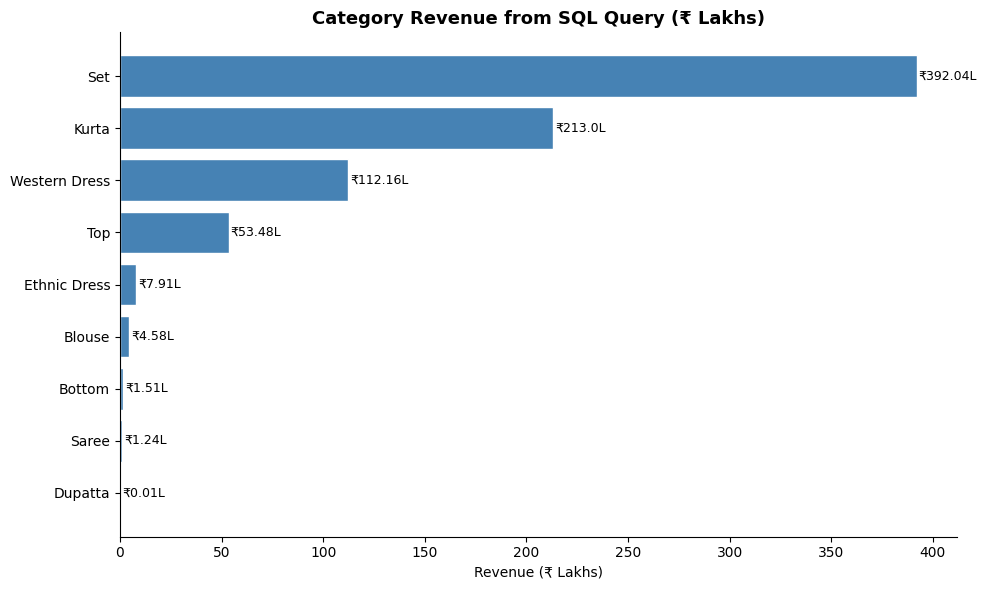

In [32]:
# Query result ko directly chart banao
import matplotlib.pyplot as plt

# Category Revenue chart from SQL
cat_data = pd.read_sql("""
    SELECT "Category",
           ROUND(SUM("Amount")/100000, 2) AS revenue_lakhs
    FROM amazon_sales
    WHERE "Amount" > 0
    GROUP BY "Category"
    ORDER BY revenue_lakhs DESC
""", conn)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_data['Category'], cat_data['revenue_lakhs'],
               color='steelblue', edgecolor='white')
ax.invert_yaxis()
ax.set_title('Category Revenue from SQL Query (₹ Lakhs)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Revenue (₹ Lakhs)')
ax.spines[['top','right']].set_visible(False)

for bar, val in zip(bars, cat_data['revenue_lakhs']):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
            f'₹{val}L', va='center', fontsize=9)
plt.tight_layout()
plt.show()